# 08b Fixed-Base Steering v1

이 노트북은 08a에서 만든 geometry feature를 실제 조향값 `steer_norm`으로 변환한다.

핵심 아이디어는 **화면 중앙 하단에 고정된 수직 막대**다.

```text
08a geometry:
  mode, local_slope, center_error

08b steering:
  fixed base ray가 얼마나 좌우로 기울어지는지 계산
  → steer_norm으로 변환
```

이 노트북도 최종 실주행 코드를 바로 만드는 것이 아니라, field3 sequence에서 조향 방향이 사람 눈에 납득되는지 확인하는 replay 노트북이다.

## 1. Mode별 steering 원칙

이번 구조는 mode별 역할을 분리한다.

```text
both:
  lane 중앙 오차(center_error)를 강하게 반영한다.
  local_slope는 보조로 반영한다.

single:
  한쪽 lane의 x 위치는 쓰지 않는다.
  local_slope만 사용한다.

lost:
  새 geometry가 없으므로 마지막 steer를 짧게 유지하고, 길어지면 천천히 감쇠한다.
```

이렇게 하면 single lane에서 left/right side 판단, offset target, aim_x drift 문제를 피할 수 있다.

In [1]:
from pathlib import Path
import json
import math

import cv2
import numpy as np
import pandas as pd
from IPython.display import Image, Video, display

PROJECT_ROOT = Path(r"~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization")
EXP_ROOT = PROJECT_ROOT / "10_experiments" / "12_clrkdnet_supervised_rebuild"
REVIEW_ROOT = EXP_ROOT / "review_outputs" / "08b_fixed_base_steering_v1"
GEOM_ROOT = EXP_ROOT / "review_outputs" / "08a_lane_geometry_probe_v1"
OLD_08_ROOT = EXP_ROOT / "review_outputs" / "08_driving_postprocess_contract_v1"
FIELD3_ROOT = PROJECT_ROOT / "20_shared_assets" / "dataset" / "lane" / "raw" / "field3"

GEOM_CSV = GEOM_ROOT / "tables" / "field3_fixed_base_geometry_features.csv"
GEOM_CONFIG_JSON = GEOM_ROOT / "config" / "fixed_base_geometry_config_v1.json"
DECODED_JSONL = OLD_08_ROOT / "tangent_decoded_lanes_field3.jsonl"

CONFIG_DIR = REVIEW_ROOT / "config"
TABLE_DIR = REVIEW_ROOT / "tables"
OVERLAY_DIR = REVIEW_ROOT / "overlays"
VIDEO_DIR = REVIEW_ROOT / "videos"
for d in [CONFIG_DIR, TABLE_DIR, OVERLAY_DIR, VIDEO_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RAW_W = 1296
RAW_H = 972
CUT_HEIGHT = 445
IMAGE_CENTER_X = RAW_W / 2.0

print("geometry csv:", GEOM_CSV)
print("decoded lanes:", DECODED_JSONL)
print("review root:", REVIEW_ROOT)

geometry csv: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\08a_lane_geometry_probe_v1\tables\field3_fixed_base_geometry_features.csv
decoded lanes: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\08_driving_postprocess_contract_v1\tangent_decoded_lanes_field3.jsonl
review root: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\08b_fixed_base_steering_v1


In [2]:
def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def write_json(path, obj):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(obj, indent=2, ensure_ascii=False), encoding="utf-8")


def imread_bgr(path):
    data = np.fromfile(str(path), dtype=np.uint8)
    img = cv2.imdecode(data, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(path)
    return img


def imwrite_bgr(path, img):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    ext = path.suffix or ".jpg"
    ok, buf = cv2.imencode(ext, img)
    if not ok:
        raise RuntimeError(f"cv2.imencode failed: {path}")
    buf.tofile(str(path))


def even_sample(items, n):
    items = list(items)
    if len(items) <= n:
        return items
    idx = np.linspace(0, len(items) - 1, n).round().astype(int)
    return [items[i] for i in idx]


def resize_to_width(img, width):
    h, w = img.shape[:2]
    if w == width:
        return img
    scale = width / float(w)
    return cv2.resize(img, (width, int(round(h * scale))), interpolation=cv2.INTER_AREA)


def make_sheet(images, out_path, cols=3, tile_w=720, pad=10, bg=(245, 245, 245)):
    if not images:
        return None
    tiles = [resize_to_width(img, tile_w) for img in images]
    tile_h = max(t.shape[0] for t in tiles)
    rows = int(math.ceil(len(tiles) / cols))
    sheet = np.full((rows * tile_h + (rows + 1) * pad, cols * tile_w + (cols + 1) * pad, 3), bg, dtype=np.uint8)
    for i, tile in enumerate(tiles):
        r, c = divmod(i, cols)
        y0 = pad + r * (tile_h + pad)
        x0 = pad + c * (tile_w + pad)
        sheet[y0:y0 + tile.shape[0], x0:x0 + tile.shape[1]] = tile
    imwrite_bgr(out_path, sheet)
    return out_path

print("helpers ready")

helpers ready


In [3]:
assert GEOM_CSV.exists(), f"Run 08a first: {GEOM_CSV}"
assert GEOM_CONFIG_JSON.exists(), f"Run 08a first: {GEOM_CONFIG_JSON}"
assert DECODED_JSONL.exists(), DECODED_JSONL

geom_config = read_json(GEOM_CONFIG_JSON)
features_df = pd.read_csv(GEOM_CSV)

# Load decoded lanes for visualization only.
decoded_by_key = {}
with DECODED_JSONL.open("r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
        obj = json.loads(line)
        decoded_by_key[obj["key"]] = obj["lanes"]

print("features:", len(features_df))
display(features_df.groupby("mode").size().to_frame("frames"))
display(features_df.head())

features: 1730


,frames
mode,
both,708
lost,259
single,763


,key,image_path,decoded_lane_count,mode,local_slope,center_error,lane_center_x,single_x_mid,pair_gap_px,mean_conf,selected_lane_indices,feature_count,reason
0,field3::000000_mixed_drive_auto_20260501_19123...,~\02_Projects\University\26-1_Em...,2,both,-0.089528,-0.156709,546.452744,NaN,1090.572785,0.853483,"[1, 0]",2,valid pair: use center_error + averaged local_...
1,field3::000001_mixed_drive_auto_20260501_19123...,~\02_Projects\University\26-1_Em...,2,both,-0.089961,-0.156662,546.483164,NaN,1090.732195,0.852661,"[1, 0]",2,valid pair: use center_error + averaged local_...
2,field3::000002_mixed_drive_auto_20260501_19123...,~\02_Projects\University\26-1_Em...,2,both,-0.092485,-0.156486,546.597171,NaN,1090.634049,0.853379,"[1, 0]",2,valid pair: use center_error + averaged local_...
3,field3::000003_mixed_drive_auto_20260501_19123...,~\02_Projects\University\26-1_Em...,2,both,-0.091756,-0.156603,546.521521,NaN,1090.707508,0.854034,"[1, 0]",2,valid pair: use center_error + averaged local_...
4,field3::000004_mixed_drive_auto_20260501_19123...,~\02_Projects\University\26-1_Em...,2,both,-0.090073,-0.156831,546.373534,NaN,1090.521980,0.853970,"[1, 0]",2,valid pair: use center_error + averaged local_...


## 2. Steering config 초안

아래 값은 정답이 아니라 **해석 가능한 시작점**이다.

| 값 | 해석 |
|---|---|
| `both_center_weight` | both lane에서 중앙 복귀를 얼마나 강하게 할지 |
| `both_slope_weight` | both lane에서 기울기를 얼마나 보조 반영할지 |
| `single_slope_weight` | single lane에서 기울기만으로 얼마나 회전할지 |
| `both_alpha` | both mode 조향 반응 속도 |
| `single_alpha` | single mode 조향 반응 속도 |
| `lost_hold_frames` | lane lost 시 마지막 조향을 유지할 frame 수 |
| `lost_decay` | lost가 길어질 때 마지막 조향 감쇠율 |
| `max_steer_norm` | 최종 조향 절댓값 제한 |

부호 convention은 단순히 **이미지 기준 오른쪽이 positive**다. 실제 모터 방향은 나중에 `steer_sign`으로 맞춘다.

In [4]:
STEERING_CONFIG = {
    "name": "fixed_base_mode_steering_v1",
    "sign_convention": "positive steer points to image-right; motor steer_sign can flip hardware direction",
    "both_center_weight": 1.2,
    "both_slope_weight": 0.3,
    "single_slope_weight": 0.5,
    "both_alpha": 0.7,
    "single_alpha": 0.5,
    "lost_hold_frames": 5,
    "lost_decay": 0.95,
    "max_steer_norm": 0.7,
    "large_jump_threshold": 0.25,
    "visual_steer_px": 380.0,
}
write_json(CONFIG_DIR / "fixed_base_steering_config_v1.json", STEERING_CONFIG)
display(pd.Series(STEERING_CONFIG).to_frame("value"))
print("saved:", CONFIG_DIR / "fixed_base_steering_config_v1.json")

,value
name,fixed_base_mode_steering_v1
sign_convention,positive steer points to image-right; motor st...
both_center_weight,1.2
both_slope_weight,0.3
single_slope_weight,0.5
both_alpha,0.7
single_alpha,0.5
lost_hold_frames,5
lost_decay,0.95
max_steer_norm,0.7


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\08b_fixed_base_steering_v1\config\fixed_base_steering_config_v1.json


## 3. Mode별 steer 계산

계산식은 일부러 단순하게 둔다.

```python
both:
  raw = both_center_weight * center_error + both_slope_weight * local_slope

single:
  raw = single_slope_weight * local_slope

lost:
  raw = last_steer                  # lost_hold_frames까지
  raw = last_steer * lost_decay     # 그 이후
```

그 다음 mode별 alpha로 smoothing한다.

In [5]:
def clip_steer(v, cfg):
    return float(np.clip(v, -cfg["max_steer_norm"], cfg["max_steer_norm"]))


def compute_raw_steer(row, last_steer, lost_frames, cfg):
    mode = row["mode"]
    slope = 0.0 if not np.isfinite(row["local_slope"]) else float(row["local_slope"])
    center_error = 0.0 if not np.isfinite(row["center_error"]) else float(row["center_error"])

    if mode == "both":
        raw = cfg["both_center_weight"] * center_error + cfg["both_slope_weight"] * slope
        alpha = cfg["both_alpha"]
        reason = "both: center strong + slope mild"
        next_lost_frames = 0
    elif mode == "single":
        raw = cfg["single_slope_weight"] * slope
        alpha = cfg["single_alpha"]
        reason = "single: slope only"
        next_lost_frames = 0
    else:
        next_lost_frames = lost_frames + 1
        if next_lost_frames <= int(cfg["lost_hold_frames"]):
            raw = last_steer
            reason = "lost: hold last steer"
        else:
            raw = last_steer * cfg["lost_decay"]
            reason = "lost: decay last steer"
        alpha = 1.0
    return float(raw), float(alpha), int(next_lost_frames), reason


def run_steering_sequence(features_df, cfg):
    rows = []
    last_steer = 0.0
    lost_frames = 0
    for i, row in features_df.reset_index(drop=True).iterrows():
        raw, alpha, lost_frames_next, reason = compute_raw_steer(row, last_steer, lost_frames, cfg)
        target = clip_steer(raw, cfg)
        steer = clip_steer((1.0 - alpha) * last_steer + alpha * target, cfg)
        steer_delta = steer - last_steer
        lost_frames = lost_frames_next
        out = row.to_dict()
        out.update({
            "frame_index": int(i),
            "steer_raw": float(raw),
            "steer_target": float(target),
            "steer_norm": float(steer),
            "abs_steer": float(abs(steer)),
            "steer_delta": float(steer_delta),
            "abs_steer_delta": float(abs(steer_delta)),
            "alpha": float(alpha),
            "lost_frames": int(lost_frames),
            "steering_reason": reason,
            "is_saturated": bool(abs(raw) > cfg["max_steer_norm"]),
            "is_large_jump": bool(abs(steer_delta) >= cfg["large_jump_threshold"]),
        })
        rows.append(out)
        last_steer = steer
    return pd.DataFrame(rows)

steering_df = run_steering_sequence(features_df, STEERING_CONFIG)
steering_df.to_csv(TABLE_DIR / "field3_fixed_base_steering_rows.csv", index=False, encoding="utf-8-sig")
print("saved:", TABLE_DIR / "field3_fixed_base_steering_rows.csv")
display(steering_df.head())

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\08b_fixed_base_steering_v1\tables\field3_fixed_base_steering_rows.csv


,key,image_path,decoded_lane_count,mode,local_slope,center_error,lane_center_x,single_x_mid,pair_gap_px,mean_conf,...,steer_target,steer_norm,abs_steer,steer_delta,abs_steer_delta,alpha,lost_frames,steering_reason,is_saturated,is_large_jump
0,field3::000000_mixed_drive_auto_20260501_19123...,~\02_Projects\University\26-1_Em...,2,both,-0.089528,-0.156709,546.452744,NaN,1090.572785,0.853483,...,-0.214909,-0.150436,0.150436,-0.150436,0.150436,0.7,0,both: center strong + slope mild,False,False
1,field3::000001_mixed_drive_auto_20260501_19123...,~\02_Projects\University\26-1_Em...,2,both,-0.089961,-0.156662,546.483164,NaN,1090.732195,0.852661,...,-0.214983,-0.195619,0.195619,-0.045182,0.045182,0.7,0,both: center strong + slope mild,False,False
2,field3::000002_mixed_drive_auto_20260501_19123...,~\02_Projects\University\26-1_Em...,2,both,-0.092485,-0.156486,546.597171,NaN,1090.634049,0.853379,...,-0.215529,-0.209556,0.209556,-0.013937,0.013937,0.7,0,both: center strong + slope mild,False,False
3,field3::000003_mixed_drive_auto_20260501_19123...,~\02_Projects\University\26-1_Em...,2,both,-0.091756,-0.156603,546.521521,NaN,1090.707508,0.854034,...,-0.215450,-0.213682,0.213682,-0.004126,0.004126,0.7,0,both: center strong + slope mild,False,False
4,field3::000004_mixed_drive_auto_20260501_19123...,~\02_Projects\University\26-1_Em...,2,both,-0.090073,-0.156831,546.373534,NaN,1090.521980,0.853970,...,-0.215219,-0.214758,0.214758,-0.001076,0.001076,0.7,0,both: center strong + slope mild,False,False


In [6]:
summary_by_mode = steering_df.groupby("mode").agg(
    frames=("key", "count"),
    mean_steer=("steer_norm", "mean"),
    mean_abs_steer=("abs_steer", "mean"),
    p90_abs_steer=("abs_steer", lambda s: float(np.percentile(s, 90))),
    max_abs_steer=("abs_steer", "max"),
    mean_abs_delta=("abs_steer_delta", "mean"),
    large_jump_rate=("is_large_jump", "mean"),
    saturation_rate=("is_saturated", "mean"),
).reset_index()
summary_by_mode.to_csv(TABLE_DIR / "steering_summary_by_mode.csv", index=False, encoding="utf-8-sig")

overall_summary = {
    "frames": int(len(steering_df)),
    "mean_abs_steer": float(steering_df["abs_steer"].mean()),
    "p90_abs_steer": float(np.percentile(steering_df["abs_steer"], 90)),
    "p95_abs_steer": float(np.percentile(steering_df["abs_steer"], 95)),
    "max_abs_steer": float(steering_df["abs_steer"].max()),
    "mean_abs_steer_delta": float(steering_df["abs_steer_delta"].mean()),
    "large_jump_rate": float(steering_df["is_large_jump"].mean()),
    "saturation_rate": float(steering_df["is_saturated"].mean()),
    "mode_counts": {str(k): int(v) for k, v in steering_df["mode"].value_counts().to_dict().items()},
}

display(summary_by_mode)
print(json.dumps(overall_summary, indent=2, ensure_ascii=False))

,mode,frames,mean_steer,mean_abs_steer,p90_abs_steer,max_abs_steer,mean_abs_delta,large_jump_rate,saturation_rate
0,both,708,-0.057773,0.139247,0.296743,0.503489,0.051676,0.009887,0.000000
1,lost,259,-0.128432,0.206624,0.574810,0.699939,0.002703,0.000000,0.000000
2,single,763,-0.091939,0.363512,0.674182,0.699999,0.044223,0.020970,0.174312


{
  "frames": 1730,
  "mean_abs_steer": 0.24824432038830044,
  "p90_abs_steer": 0.5748099065266564,
  "p95_abs_steer": 0.6601295313335614,
  "max_abs_steer": 0.6999994023481111,
  "mean_abs_steer_delta": 0.04105701352262024,
  "large_jump_rate": 0.013294797687861272,
  "saturation_rate": 0.07687861271676301,
  "mode_counts": {
    "single": 763,
    "both": 708,
    "lost": 259
  }
}


In [7]:
# Visualization helpers. These duplicate small geometry helpers so 08b can run independently after 08a.
def normalize_lane_points(lane):
    pts = np.array(lane.get("points", []), dtype=np.float32)
    if pts.ndim != 2 or pts.shape[1] != 2:
        return None
    valid = np.isfinite(pts).all(axis=1)
    pts = pts[valid]
    if len(pts) < 2:
        return None
    return pts[np.argsort(pts[:, 1])]


def interp_or_nearest_x(points, query_y, max_y_distance):
    ys = points[:, 1]
    xs = points[:, 0]
    if len(points) < 2:
        return np.nan
    y_min, y_max = float(ys.min()), float(ys.max())
    if y_min <= query_y <= y_max:
        return float(np.interp(query_y, ys, xs))
    nearest_idx = int(np.argmin(np.abs(ys - query_y)))
    if abs(float(ys[nearest_idx]) - query_y) <= max_y_distance:
        return float(xs[nearest_idx])
    return np.nan


def lane_feature(lane, cfg, lane_index):
    pts = normalize_lane_points(lane)
    if pts is None or len(pts) < int(cfg["min_points"]):
        return None
    y_span = float(pts[:, 1].max() - pts[:, 1].min())
    if y_span < float(cfg["min_y_span"]):
        return None
    x_top = interp_or_nearest_x(pts, cfg["top_y"], cfg["max_y_distance"])
    x_mid = interp_or_nearest_x(pts, cfg["mid_y"], cfg["max_y_distance"])
    x_bottom = interp_or_nearest_x(pts, cfg["bottom_y"], cfg["max_y_distance"])
    if not np.isfinite([x_top, x_mid, x_bottom]).all():
        return None
    return {
        "lane_index": int(lane_index),
        "points": pts,
        "x_top": float(x_top),
        "x_mid": float(x_mid),
        "x_bottom": float(x_bottom),
    }


def extract_features_for_overlay(lanes, cfg):
    feats = []
    for i, lane in enumerate(lanes):
        feat = lane_feature(lane, cfg, i)
        if feat is not None:
            feats.append(feat)
    return feats


def draw_dashed_line(img, p1, p2, color, thickness=2, dash=12, gap=8):
    p1 = np.array(p1, dtype=np.float32)
    p2 = np.array(p2, dtype=np.float32)
    dist = float(np.linalg.norm(p2 - p1))
    if dist < 1:
        return
    direction = (p2 - p1) / dist
    t = 0.0
    while t < dist:
        start = p1 + direction * t
        end = p1 + direction * min(t + dash, dist)
        cv2.line(img, tuple(start.astype(int)), tuple(end.astype(int)), color, thickness, cv2.LINE_AA)
        t += dash + gap


def draw_lane_points(img, lane, color=(40, 220, 80)):
    pts = normalize_lane_points(lane)
    if pts is None or len(pts) < 2:
        return
    pts_i = pts.astype(np.int32)
    for p in pts_i:
        cv2.circle(img, tuple(p), 3, color, -1, cv2.LINE_AA)
    cv2.polylines(img, [pts_i.reshape(-1, 1, 2)], False, color, 2, cv2.LINE_AA)


def draw_feature_line(img, feat, selected):
    color = (255, 190, 50) if selected else (160, 160, 160)
    thickness = 3 if selected else 1
    p_top = (int(round(feat["x_top"])), int(round(geom_config["top_y"])))
    p_bottom = (int(round(feat["x_bottom"])), int(round(geom_config["bottom_y"])))
    cv2.line(img, p_bottom, p_top, color, thickness, cv2.LINE_AA)
    cv2.circle(img, (int(round(feat["x_mid"])), int(round(geom_config["mid_y"]))), 5, color, -1, cv2.LINE_AA)


def parse_selected_indices(value):
    if isinstance(value, str):
        try:
            return set(json.loads(value))
        except Exception:
            return set()
    if isinstance(value, (list, tuple, set)):
        return set(value)
    return set()


def overlay_steering(row, scale_width=960):
    bgr = imread_bgr(row["image_path"])
    out = bgr.copy()
    lanes = decoded_by_key.get(row["key"], [])
    selected = parse_selected_indices(row.get("selected_lane_indices", "[]"))
    feats = extract_features_for_overlay(lanes, geom_config)

    for lane in lanes:
        draw_lane_points(out, lane, color=(40, 220, 80))
    for feat in feats:
        draw_feature_line(out, feat, feat["lane_index"] in selected)

    for y, label, color in [
        (geom_config["top_y"], "top_y=0.8", (80, 150, 255)),
        (geom_config["mid_y"], "mid_y=0.9", (80, 80, 255)),
        (geom_config["bottom_y"], "bottom_y=1.0", (80, 150, 255)),
    ]:
        y_i = int(round(y))
        cv2.line(out, (0, y_i), (RAW_W - 1, y_i), color, 1, cv2.LINE_AA)

    base = (int(round(IMAGE_CENTER_X)), int(round(geom_config["bottom_y"])))
    vertical_tip = (int(round(IMAGE_CENTER_X)), int(round(geom_config["top_y"])))
    cv2.line(out, base, vertical_tip, (230, 230, 230), 3, cv2.LINE_AA)

    if np.isfinite(row["lane_center_x"]):
        cx = int(round(row["lane_center_x"]))
        y_mid = int(round(geom_config["mid_y"]))
        cv2.circle(out, (cx, y_mid), 8, (0, 170, 255), -1, cv2.LINE_AA)
        cv2.line(out, (int(IMAGE_CENTER_X), y_mid), (cx, y_mid), (0, 170, 255), 3, cv2.LINE_AA)

    # raw target arrow, before smoothing, in gray/purple thin line
    raw_x = int(round(np.clip(IMAGE_CENTER_X + row["steer_target"] * STEERING_CONFIG["visual_steer_px"], 0, RAW_W - 1)))
    raw_tip = (raw_x, int(round(geom_config["top_y"])))
    cv2.arrowedLine(out, base, raw_tip, (180, 120, 180), 2, cv2.LINE_AA, tipLength=0.18)

    # final smoothed steer arrow
    final_x = int(round(np.clip(IMAGE_CENTER_X + row["steer_norm"] * STEERING_CONFIG["visual_steer_px"], 0, RAW_W - 1)))
    final_tip = (final_x, int(round(geom_config["top_y"])))
    cv2.arrowedLine(out, base, final_tip, (255, 0, 180), 5, cv2.LINE_AA, tipLength=0.22)

    text_lines = [
        f"mode={row['mode']} steer={row['steer_norm']:+.3f} raw={row['steer_raw']:+.3f} target={row['steer_target']:+.3f}",
        f"slope={row['local_slope']:+.3f} center={row['center_error']:+.3f} alpha={row['alpha']:.2f}",
        f"lost={int(row['lost_frames'])} delta={row['steer_delta']:+.3f} {row['steering_reason']}",
    ]
    x0, y0 = 18, 34
    for i, txt in enumerate(text_lines):
        y = y0 + i * 28
        cv2.putText(out, txt, (x0 + 2, y + 2), cv2.FONT_HERSHEY_SIMPLEX, 0.72, (0, 0, 0), 4, cv2.LINE_AA)
        cv2.putText(out, txt, (x0, y), cv2.FONT_HERSHEY_SIMPLEX, 0.72, (245, 245, 245), 2, cv2.LINE_AA)
    return resize_to_width(out, scale_width)

print("overlay helpers ready")

overlay helpers ready


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\08b_fixed_base_steering_v1\overlays\fixed_base_steering_even_sample_sheet.jpg


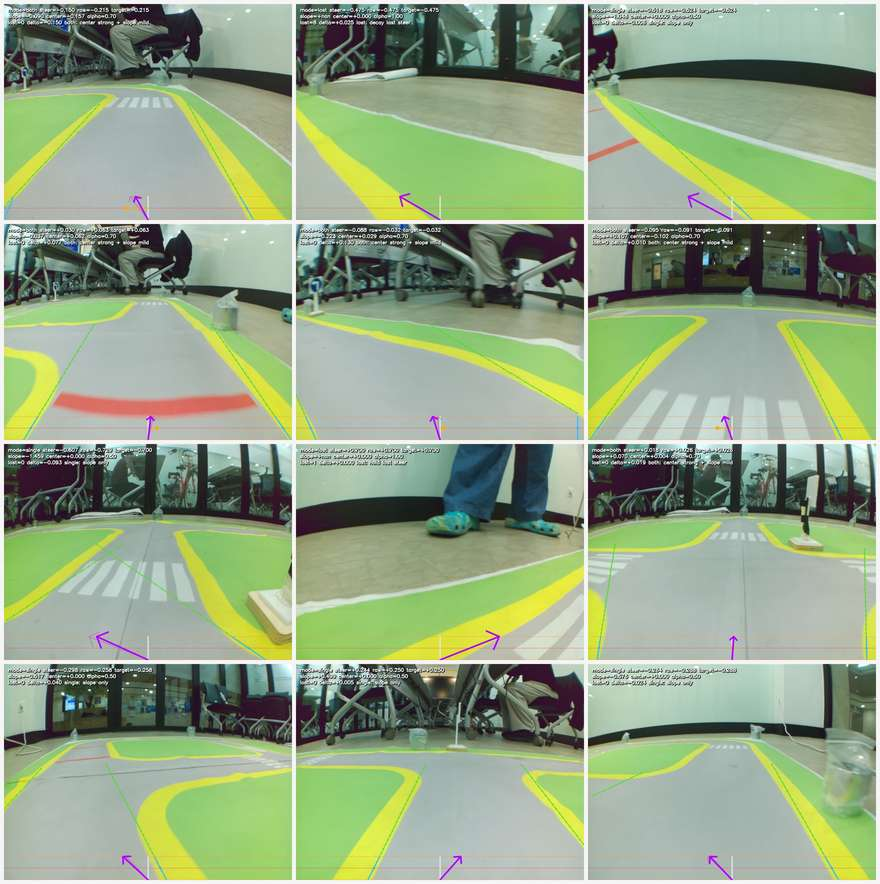

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\08b_fixed_base_steering_v1\overlays\fixed_base_steering_by_mode_sheet.jpg


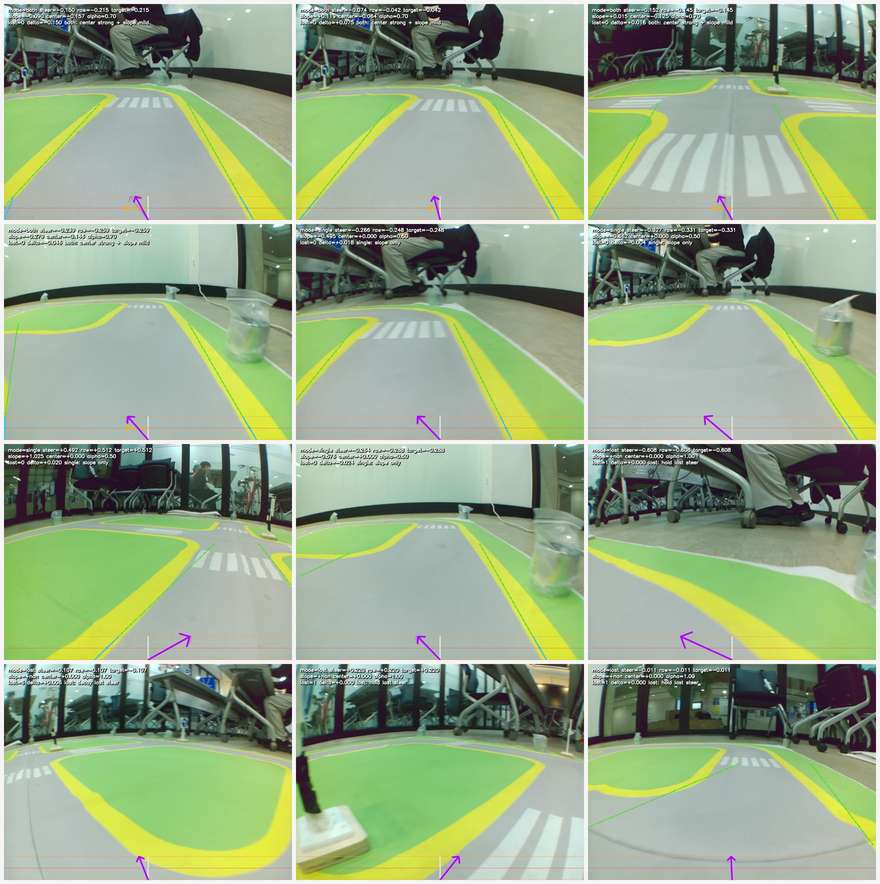

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\08b_fixed_base_steering_v1\overlays\fixed_base_steering_high_steer_sheet.jpg


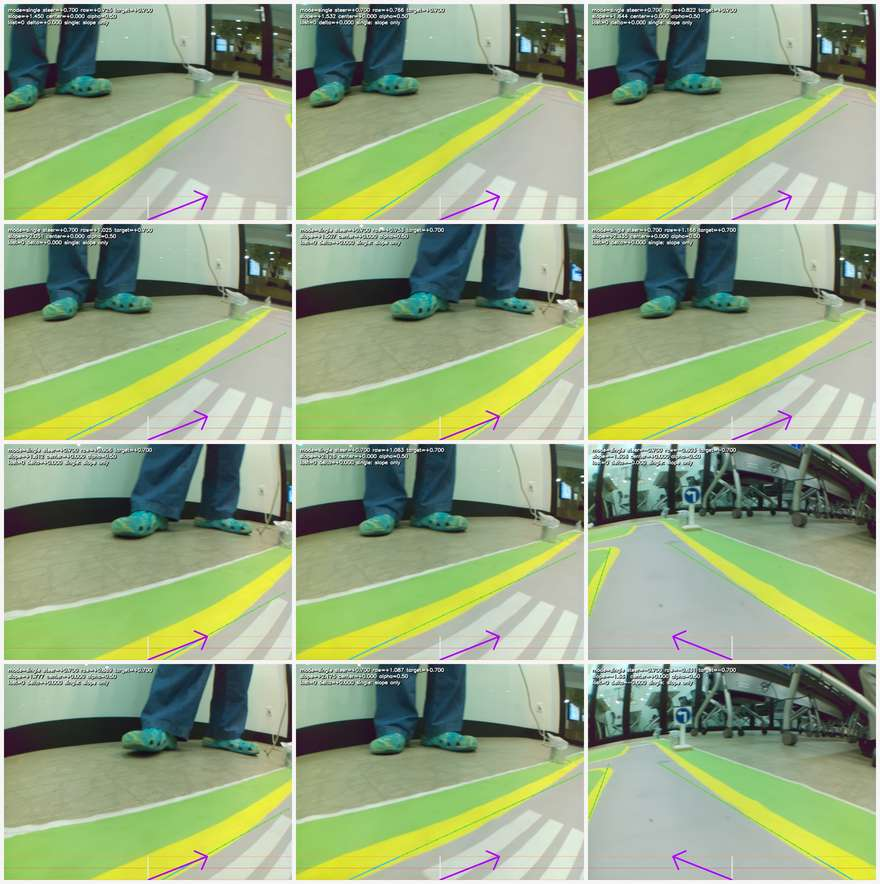

In [8]:
steering_rows = steering_df.to_dict("records")

# 1) evenly sampled sequence overview
even_rows = even_sample(steering_rows, 12)
even_imgs = [overlay_steering(r, scale_width=720) for r in even_rows]
even_path = OVERLAY_DIR / "fixed_base_steering_even_sample_sheet.jpg"
make_sheet(even_imgs, even_path, cols=3, tile_w=720)
print("saved:", even_path)
display(Image(filename=str(even_path)))

# 2) mode-balanced sheet
mode_sample = []
for mode in ["both", "single", "lost"]:
    mode_rows = [r for r in steering_rows if r["mode"] == mode]
    mode_sample.extend(even_sample(mode_rows, 4))
mode_imgs = [overlay_steering(r, scale_width=720) for r in mode_sample]
mode_path = OVERLAY_DIR / "fixed_base_steering_by_mode_sheet.jpg"
make_sheet(mode_imgs, mode_path, cols=3, tile_w=720)
print("saved:", mode_path)
display(Image(filename=str(mode_path)))

# 3) high steer / saturated-looking frames
high_df = steering_df.sort_values("abs_steer", ascending=False).head(12)
high_rows = high_df.to_dict("records")
high_imgs = [overlay_steering(r, scale_width=720) for r in high_rows]
high_path = OVERLAY_DIR / "fixed_base_steering_high_steer_sheet.jpg"
make_sheet(high_imgs, high_path, cols=3, tile_w=720)
print("saved:", high_path)
display(Image(filename=str(high_path)))

## 4. Field3 steering video

영상에서 확인할 것은 다음이다.

- 분홍 두꺼운 화살표: smoothing 이후 최종 `steer_norm`
- 보라 얇은 화살표: raw target steer
- 흰색 수직 막대: fixed base 기준선
- 주황 표시: both lane center error

중요한 판단 기준:

```text
both에서 중앙 복귀가 충분한가?
single에서 곡선 방향으로 충분히 도는가?
lost에서 steer가 너무 빨리 죽거나 반대로 오래 과도하게 유지되지 않는가?
```

In [9]:
def write_steering_video(rows, out_path, fps=12, scale_width=960, max_frames=None):
    out_path = Path(out_path)
    selected = rows if max_frames is None else rows[:max_frames]
    if not selected:
        return None
    first = overlay_steering(selected[0], scale_width=scale_width)
    h, w = first.shape[:2]
    writer = cv2.VideoWriter(str(out_path), cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))
    if not writer.isOpened():
        fallback = out_path.with_suffix(".avi")
        writer = cv2.VideoWriter(str(fallback), cv2.VideoWriter_fourcc(*"XVID"), fps, (w, h))
        out_path = fallback
    assert writer.isOpened(), "VideoWriter failed"
    writer.write(first)
    for i, row in enumerate(selected[1:], start=1):
        frame = overlay_steering(row, scale_width=scale_width)
        if frame.shape[:2] != (h, w):
            frame = cv2.resize(frame, (w, h), interpolation=cv2.INTER_AREA)
        writer.write(frame)
        if i % 300 == 0:
            print(f"video frame {i}/{len(selected)}")
    writer.release()
    return out_path

VIDEO_MAX_FRAMES = None
video_path = write_steering_video(
    steering_rows,
    VIDEO_DIR / "fixed_base_steering_field3_full.mp4",
    fps=12,
    scale_width=960,
    max_frames=VIDEO_MAX_FRAMES,
)
print("saved:", video_path)
display(Video(str(video_path), embed=False))

video frame 300/1730
video frame 600/1730
video frame 900/1730
video frame 1200/1730
video frame 1500/1730
saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\08b_fixed_base_steering_v1\videos\fixed_base_steering_field3_full.mp4


In [10]:
report = {
    "name": "08b_fixed_base_steering_v1",
    "description": "Mode-specific steering from 08a fixed-base geometry features. Both uses center_error + mild slope; single uses slope only; lost holds/decays last steer.",
    "input_geometry_csv": str(GEOM_CSV),
    "config": STEERING_CONFIG,
    "overall_summary": overall_summary,
    "summary_by_mode": summary_by_mode.to_dict(orient="records"),
    "outputs": {
        "steering_rows_csv": str(TABLE_DIR / "field3_fixed_base_steering_rows.csv"),
        "summary_by_mode_csv": str(TABLE_DIR / "steering_summary_by_mode.csv"),
        "even_sheet": str(even_path),
        "mode_sheet": str(mode_path),
        "high_steer_sheet": str(high_path),
        "video": str(video_path),
    },
    "next": [
        "영상에서 both/single/lost별 조향 방향을 검수한다.",
        "필요하면 both_center_weight, single_slope_weight, lost_decay부터 수정한다.",
        "확정 후 lane runtime package의 steering 함수로 이식한다."
    ],
}
write_json(REVIEW_ROOT / "fixed_base_steering_summary_v1.json", report)
print("saved:", REVIEW_ROOT / "fixed_base_steering_summary_v1.json")
print(json.dumps(overall_summary, indent=2, ensure_ascii=False))

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\08b_fixed_base_steering_v1\fixed_base_steering_summary_v1.json
{
  "frames": 1730,
  "mean_abs_steer": 0.24824432038830044,
  "p90_abs_steer": 0.5748099065266564,
  "p95_abs_steer": 0.6601295313335614,
  "max_abs_steer": 0.6999994023481111,
  "mean_abs_steer_delta": 0.04105701352262024,
  "large_jump_rate": 0.013294797687861272,
  "saturation_rate": 0.07687861271676301,
  "mode_counts": {
    "single": 763,
    "both": 708,
    "lost": 259
  }
}


## 5. 해석 가이드

현장에서 수정할 가능성이 큰 값은 아래 네 개다.

```text
both_center_weight:
  양쪽 lane이 보일 때 차선 중앙으로 복귀하는 힘

single_slope_weight:
  한쪽 lane만 보일 때 곡선 방향으로 도는 힘

lost_decay:
  lane을 놓쳤을 때 마지막 조향을 얼마나 오래 유지할지

max_steer_norm:
  전체 조향 제한값
```

기본적으로는 이 순서로 조절한다.

```text
1. 곡선에서 덜 돌면 single_slope_weight 증가
2. both에서 중앙 복귀가 느리면 both_center_weight 증가
3. lost에서 너무 빨리 직진하면 lost_decay 증가
4. 조향이 너무 과하면 max_steer_norm 감소
```